# 01 DATA UNDERSTANDING

# Credit Risk Modelling – Data Understanding

## Objective

Understand the Home Credit application and bureau datasets, inspect their structure, identify the target variable, and perform an initial assessment of data quality.

## Inputs

- application_train_sample.csv
- bureau_sample.csv

## Outputs

- Dataset dimensions
- Column summaries
- Target distribution
- Missing-value summary
- Initial observations for feature engineering

In [57]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import warnings
warnings.filterwarnings('ignore')

In [59]:
# Load datasets

app = pd.read_csv('application_train.csv', nrows=50000)
bureau = pd.read_csv('bureau.csv', nrows = 100000)

In [60]:
# Dataset Dimensions

print("Application Shape:", app.shape)
print("Bureau Shape:", bureau.shape)

Application Shape: (50000, 122)
Bureau Shape: (100000, 17)


In [61]:
app.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [62]:
bureau.columns.tolist()

['SK_ID_CURR',
 'SK_ID_BUREAU',
 'CREDIT_ACTIVE',
 'CREDIT_CURRENCY',
 'DAYS_CREDIT',
 'CREDIT_DAY_OVERDUE',
 'DAYS_CREDIT_ENDDATE',
 'DAYS_ENDDATE_FACT',
 'AMT_CREDIT_MAX_OVERDUE',
 'CNT_CREDIT_PROLONG',
 'AMT_CREDIT_SUM',
 'AMT_CREDIT_SUM_DEBT',
 'AMT_CREDIT_SUM_LIMIT',
 'AMT_CREDIT_SUM_OVERDUE',
 'CREDIT_TYPE',
 'DAYS_CREDIT_UPDATE',
 'AMT_ANNUITY']

In [63]:
app.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 52.9 MB


In [64]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [65]:
app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,49999.000000,4.996200e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,17049.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49999.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,21827.000000,4.987400e+04,40055.000000,24614.000000,20800.000000,25605.000000,16760.000000,15039.000000,23348.000000,24804.000000,25124.000000,16105.000000,20278.000000,15773.000000,24862.000000,15285.000000,22427.000000,24614.000000,20800.000000,25605.000000,16760.000000,15039.000000,23348.000000,24804.000000,25124.000000,16105.000000,20278.000000,15773.000000,24862.000000,15285.000000,22427.000000,24614.000000,20800.000000,25605.000000,16760.000000,15039.000000,23348.000000,24804.000000,25124.000000,16105.000000,20278.000000,15773.000000,24862.000000,15285.000000,22427.000000,25851.000000,49832.000000,49832.000000,49832.000000,49832.000000,49999.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.0,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,43266.000000,43266.000000,43266.000000,43266.000000,43266.000000,43266.000000
mean,129013.787840,0.080520,0.419840,1.707655e+05,5.996955e+05,27107.158303,5.390538e+05,0.020798,-16022.110060,63218.143580,-4977.188980,-2996.790260,12.025749,0.999980,0.821480,0.199280,0.997980,0.277740,0.055660,2.158943,2.051660,2.030720,12.052600,0.015000,0.049920,0.039640,0.079980,0.232180,0.179700,0.502257,5.138250e-01,0.511881,0.117771,0.088946,0.978036,0.751639,0.044796,0.078678,0.150551,0.225467,0.231650,0.066352,0.100436,0.107690,0.009097,0.028294,0.114444,0.088012,0.977404,0.758967,0.042663,0.074157,0.145999,0.221489,0.228260,0.064843,0.105323,0.106110,0.008224,0.027114,0.118203,0.088526,0.978031,0.754952,0.044708,0.077838,0.150037,0.225081,0.231559,0.067107,0.101737,0.108830,0.008939

In [66]:
bureau.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   SK_ID_CURR              100000 non-null  int64  
 1   SK_ID_BUREAU            100000 non-null  int64  
 2   CREDIT_ACTIVE           100000 non-null  str    
 3   CREDIT_CURRENCY         100000 non-null  str    
 4   DAYS_CREDIT             100000 non-null  int64  
 5   CREDIT_DAY_OVERDUE      100000 non-null  int64  
 6   DAYS_CREDIT_ENDDATE     93778 non-null   float64
 7   DAYS_ENDDATE_FACT       61988 non-null   float64
 8   AMT_CREDIT_MAX_OVERDUE  34948 non-null   float64
 9   CNT_CREDIT_PROLONG      100000 non-null  int64  
 10  AMT_CREDIT_SUM          100000 non-null  float64
 11  AMT_CREDIT_SUM_DEBT     84732 non-null   float64
 12  AMT_CREDIT_SUM_LIMIT    65635 non-null   float64
 13  AMT_CREDIT_SUM_OVERDUE  100000 non-null  float64
 14  CREDIT_TYPE             100000 n

In [67]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [68]:
bureau.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,100000.0,2.782433e+05,103508.768793,100016.000,187139.00,277751.5,367482.00,456247.00
SK_ID_BUREAU,100000.0,5.467125e+06,375728.361481,5000002.000,5210441.75,5251339.5,5727309.25,6542162.00
DAYS_CREDIT,100000.0,-1.130975e+03,791.668833,-2922.000,-1643.00,-973.0,-468.00,0.00
CREDIT_DAY_OVERDUE,100000.0,8.604300e-01,36.677908,0.000,0.00,0.0,0.00,2625.00
DAYS_CREDIT_ENDDATE,93778.0,5.339559e+02,4952.596328,-41847.000,-1108.00,-306.0,509.00,31198.00
DAYS_ENDDATE_FACT,61988.0,-1.008982e+03,709.950725,-2916.000,-1474.00,-881.0,-423.00,0.00
AMT_CREDIT_MAX_OVERDUE,34948.0,4.038033e+03,85467.671412,0.000,0.00,0.0,0.00,10861812.00
CNT_CREDIT_PROLONG,100000.0,6.770000e-03,0.097182,0.000,0.00,0.0,0.00,5.00
AMT_CREDIT_SUM,100000.0,3.602870e+05,910767.417580,0.000,53500.50,130500.0,315000.00,45000000.00
AMT_CREDIT_SUM_DEBT,84732.0,1.396019e+05,624136.713610,-4705600.320,0.00,0.0,45267.75,25431079.50


In [69]:
# create a data dictionary
def create_data_dictionary(df):
    
    summary = pd.DataFrame({
        'Column': df.columns,
        'Datatype': df.dtypes.values,
        'Missing Values': df.isnull().sum().values,
        'Missing %':
            (df.isnull().mean()*100).round(2).values,
        'Unique Values':
            df.nunique().values
    })
    
    return summary

In [70]:
app_dictionary = create_data_dictionary(app)
app_dictionary

,Column,Datatype,Missing Values,Missing %,Unique Values
0,SK_ID_CURR,int64,0,0.00,50000
1,TARGET,int64,0,0.00,2
2,NAME_CONTRACT_TYPE,str,0,0.00,2
3,CODE_GENDER,str,0,0.00,3
4,FLAG_OWN_CAR,str,0,0.00,2
5,FLAG_OWN_REALTY,str,0,0.00,2
6,CNT_CHILDREN,int64,0,0.00,11
7,AMT_INCOME_TOTAL,float64,0,0.00,797
8,AMT_CREDIT,float64,0,0.00,3421
9,AMT_ANNUITY,float64,1,0.00,8807


In [71]:
bureau_dictionary = create_data_dictionary(bureau)
bureau_dictionary

,Column,Datatype,Missing Values,Missing %,Unique Values
0,SK_ID_CURR,int64,0,0.00,23121
1,SK_ID_BUREAU,int64,0,0.00,100000
2,CREDIT_ACTIVE,str,0,0.00,4
3,CREDIT_CURRENCY,str,0,0.00,4
4,DAYS_CREDIT,int64,0,0.00,2922
5,CREDIT_DAY_OVERDUE,int64,0,0.00,133
6,DAYS_CREDIT_ENDDATE,float64,6222,6.22,7222
7,DAYS_ENDDATE_FACT,float64,38012,38.01,2818
8,AMT_CREDIT_MAX_OVERDUE,float64,65052,65.05,5993
9,CNT_CREDIT_PROLONG,int64,0,0.00,6


In [72]:
# separate numerical and categorical features
num_cols = app.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Number of Numerical Features:", len(num_cols))
num_cols

Number of Numerical Features: 106


['SK_ID_CURR',
 'TARGET',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMAX_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAR

In [73]:
cat_cols = app.select_dtypes(
    include='object'
).columns.tolist()

print("Number of Categorical Features:", len(cat_cols))
cat_cols

Number of Categorical Features: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [74]:
# missing value report
missing_df = pd.DataFrame({
    'Missing Values': app.isnull().sum(),
    'Missing %':
        (app.isnull().mean()*100).round(2)
})

missing_df = (
    missing_df
    .sort_values(
        by='Missing %',
        ascending=False
    )
)

missing_df.head(20)

,Missing Values,Missing %
COMMONAREA_AVG,34961,69.92
COMMONAREA_MODE,34961,69.92
COMMONAREA_MEDI,34961,69.92
NONLIVINGAPARTMENTS_MEDI,34715,69.43
NONLIVINGAPARTMENTS_MODE,34715,69.43
NONLIVINGAPARTMENTS_AVG,34715,69.43
LIVINGAPARTMENTS_AVG,34227,68.45
LIVINGAPARTMENTS_MODE,34227,68.45
LIVINGAPARTMENTS_MEDI,34227,68.45
FONDKAPREMONT_MODE,34192,68.38


TARGET
0    45974
1     4026
Name: count, dtype: int64
TARGET
0    91.948
1     8.052
Name: proportion, dtype: float64


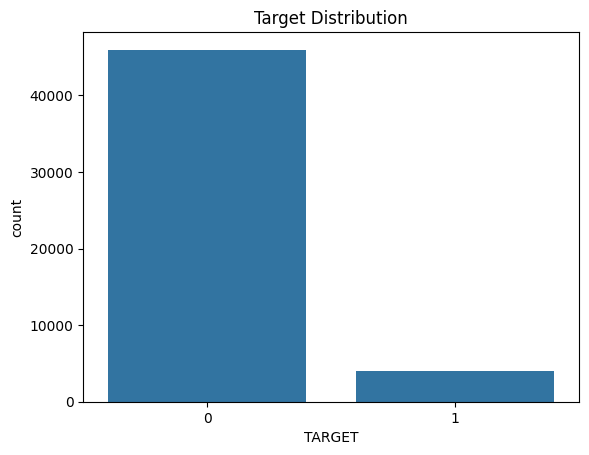

In [75]:
# TARGET DISTRIBUTION

# count
print(app['TARGET'].value_counts())

#percentage
print(app['TARGET'].value_counts(
    normalize=True
)*100)

# visualization
sns.countplot(
    x='TARGET',
    data=app
)

plt.title('Target Distribution')
plt.show()

In [76]:
# understand categorical variables
for col in cat_cols:

    print("="*60)
    print("Feature:", col)
    print()

    print(app[col].value_counts(
        dropna=False
    ))

    print()

Feature: NAME_CONTRACT_TYPE

NAME_CONTRACT_TYPE
Cash loans         45277
Revolving loans     4723
Name: count, dtype: int64

Feature: CODE_GENDER

CODE_GENDER
F      32824
M      17174
XNA        2
Name: count, dtype: int64

Feature: FLAG_OWN_CAR

FLAG_OWN_CAR
N    32950
Y    17050
Name: count, dtype: int64

Feature: FLAG_OWN_REALTY

FLAG_OWN_REALTY
Y    34692
N    15308
Name: count, dtype: int64

Feature: NAME_TYPE_SUITE

NAME_TYPE_SUITE
Unaccompanied      40436
Family              6549
Spouse, partner     1849
Children             542
Other_B              259
NaN                  192
Other_A              137
Group of people       36
Name: count, dtype: int64

Feature: NAME_INCOME_TYPE

NAME_INCOME_TYPE
Working                 26010
Commercial associate    11543
Pensioner                8920
State servant            3513
Unemployed                  6
Student                     5
Businessman                 2
Maternity leave             1
Name: count, dtype: int64

Feature: NAME_EDUCA

In [79]:
# understand numerical variables
app[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,50000.0,129013.787840,16690.844258,1.000020e+05,114570.750000,129076.500000,143439.500000,1.578760e+05
TARGET,50000.0,0.080520,0.272099,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,50000.0,0.419840,0.724034,0.000000e+00,0.000000,0.000000,1.000000,1.100000e+01
AMT_INCOME_TOTAL,50000.0,170765.525166,531813.977328,2.565000e+04,112500.000000,145800.000000,202500.000000,1.170000e+08
AMT_CREDIT,50000.0,599695.463520,402413.036950,4.500000e+04,270000.000000,514777.500000,808650.000000,4.050000e+06
AMT_ANNUITY,49999.0,27107.158303,14562.881171,2.052000e+03,16456.500000,24939.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,49962.0,539053.750120,369852.220069,4.500000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,50000.0,0.020798,0.013760,5.330000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,50000.0,-16022.110060,4361.383144,-2.518400e+04,-19644.000000,-15731.000000,-12378.750000,-7.680000e+03
DAYS_EMPLOYED,50000.0,63218.143580,140793.489022,-1.753100e+04,-2786.000000,-1221.000000,-292.000000,3.652430e+05


In [80]:
# Understand Primary Keys

app.columns[
    app.columns.str.contains('SK')
]

Index(['SK_ID_CURR'], dtype='str')

In [81]:
bureau.columns[
    bureau.columns.str.contains('SK')
]

Index(['SK_ID_CURR', 'SK_ID_BUREAU'], dtype='str')

In [83]:
# Relationship Between Tables

print(
    "Unique Customers in Application:",
    app['SK_ID_CURR'].nunique()
)

print(
    "Unique Customers in Bureau:",
    bureau['SK_ID_CURR'].nunique()
)

# Verify One-to-Many Relationship
bureau.groupby(
    'SK_ID_CURR'
).size().describe()

Unique Customers in Application: 50000
Unique Customers in Bureau: 23121


count    23121.000000
mean         4.325072
std          3.728437
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         53.000000
dtype: float64

# Key Learnings

1. The objective is to predict whether a customer will face repayment difficulties.
2. application_train contains one row per customer and includes the target variable.
3. bureau contains historical credit records from other financial institutions.
4. Tables are connected using SK_ID_CURR.
5. Relationship:
   application_train (1) -----> (many) bureau
6. The dataset contains both numerical and categorical features.
7. Several features have significant missing values.
8. The target variable is imbalanced, making accuracy alone an insufficient evaluation metric.

In [84]:
# Before starting Notebook 2

app["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.948
1     8.052
Name: proportion, dtype: float64

In [85]:
missing_df.head(10)

,Missing Values,Missing %
COMMONAREA_AVG,34961,69.92
COMMONAREA_MODE,34961,69.92
COMMONAREA_MEDI,34961,69.92
NONLIVINGAPARTMENTS_MEDI,34715,69.43
NONLIVINGAPARTMENTS_MODE,34715,69.43
NONLIVINGAPARTMENTS_AVG,34715,69.43
LIVINGAPARTMENTS_AVG,34227,68.45
LIVINGAPARTMENTS_MODE,34227,68.45
LIVINGAPARTMENTS_MEDI,34227,68.45
FONDKAPREMONT_MODE,34192,68.38
